[Previous: Architecture 4: Event-Driven and CQRS](04_Event_Driven_and_CQRS.ipynb)  |  [Course Index](../00_Start_Here.ipynb)

# Architecture 5: Choosing an Architecture

**Learning objectives.** After this module you can:

* compare the architectures from this track on the dimensions that matter and defend a choice for a given team;
* describe the usual migration path and demonstrate the strangler fig with code;
* explain Conway's law and use it deliberately;
* run the Architecture Picker and argue with its answer.

## 1. The trade-off table

| | Monolith | Modular monolith | Microservices | Event-driven services |
|---|---|---|---|---|
| Deployables | 1 | 1 | many | many |
| Network inside a request | none | none | yes, synchronous | mostly asynchronous |
| Transactions across features | trivial | trivial | sagas | sagas, eventual consistency |
| Independent team deploys | no | no | yes | yes |
| Failure isolation | none | none | per service | per service, plus buffering |
| Ops needed | basic | basic | CI/CD, monitoring, tracing, on-call | the same, plus a broker |
| Refactoring boundaries | rename | rename plus rule change | expensive | expensive |
| Best for | small teams, early product | most teams, most of the time | many teams, clear domain, uneven scaling | bursty load, many consumers, audit trails |

Nothing in the table says "modern" or "legacy". Each column is a set of costs bought for a set of benefits.

## 2. The path, and the strangler fig

Systems that end up as good services usually walked this path: **monolith** while the domain is unclear; **modular monolith** once the boundaries settle;
**extract one service** when a module needs its own deploy or scaling; repeat only where it pays.

The extraction technique is the **strangler fig**: put a router in front of the old system and move one capability at a time behind it to the new service.
Traffic shifts gradually; nothing is rewritten in one go; the old code is removed when nothing routes to it.

NEW price of lamp
legacy price of lamp
NEW price of lamp
legacy order for lamp


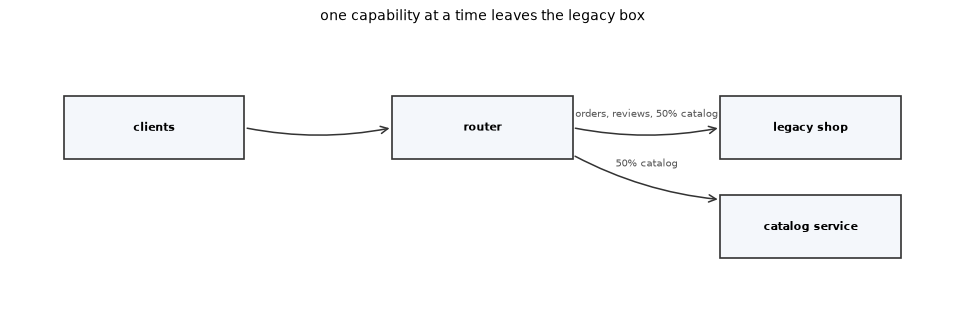

In [1]:
import random
from dplab import component_diagram, traced, trace

@traced
class LegacyShop:
    def catalog(self, item): return f"legacy price of {item}"
    def orders(self, item):  return f"legacy order for {item}"
    def reviews(self, item): return f"legacy reviews of {item}"

@traced
class CatalogService:
    def catalog(self, item): return f"NEW price of {item}"

@traced
class Router:
    # The facade in front of everything. Capabilities move one at a time; callers never notice.
    def __init__(self, legacy, new):
        self.legacy, self.new = legacy, new
        self.migrated = {}                       # capability -> share of traffic sent to the new service

    def migrate(self, capability, share):
        self.migrated[capability] = share

    def handle(self, capability, item):
        share = self.migrated.get(capability, 0.0)
        if share and random.random() < share:
            return getattr(self.new, capability)(item)
        return getattr(self.legacy, capability)(item)

random.seed(3)
router = Router(LegacyShop(), CatalogService())
with trace() as t:
    router.migrate("catalog", 0.5)               # canary: half the catalog traffic goes to the new service
    for _ in range(3):
        print(router.handle("catalog", "lamp"))
    print(router.handle("orders", "lamp"))       # untouched
t.diagram(title="strangler fig: the router decides per call; the client only sees the router", max_messages=16)
component_diagram(["clients", "router", "legacy shop", "catalog service"],
                  [("clients", "router"), ("router", "legacy shop", "orders, reviews, 50% catalog"), ("router", "catalog service", "50% catalog")],
                  layout={"clients": (0, 0), "router": (1.4, 0), "legacy shop": (2.8, 0), "catalog service": (2.8, 1)},
                  title="one capability at a time leaves the legacy box")

> **What to notice.** The migration is a number you can turn up, watch, and turn back down. Rollback is `migrate("catalog", 0)`. No big-bang cut-over.

## 3. Conway's law

"Organisations design systems that mirror their own communication structure." Three teams will produce three services, or three modules that talk through whoever
sits closest. This is not a flaw to fight; it is a lever. If you want a boundary in the software, put a team boundary there, and give the team ownership of the data behind it.
The reverse also holds: a service owned by two teams becomes a distributed monolith with a meeting schedule.

## 4. Anti-patterns worth naming

* **Resume-driven architecture.** Microservices for a three-person team because a conference talk said so. Check the ops row of the table first.
* **Distributed monolith.** Covered in Module 3: services that ship together.
* **Shared database.** Two services writing one schema: every migration is a negotiation and the boundary is fiction.
* **Big-bang rewrite.** Replacing the monolith in one release. The strangler fig exists because this almost never lands.
* **Premature splitting.** Extracting services before the domain is understood, then paying network costs to move the boundaries.

### Lab: Architecture Picker

Five questions, a ranked answer with reasons. It is a heuristic; the value is in disagreeing with it and saying why.

In [2]:
from dplab import architecture_picker

architecture_picker()

Architecture Picker (static preview). Run this cell in JupyterLab for the interactive version.


architecture,score,why
modular monolith,+7,"mid-size team: boundaries matter, the network does not yet; unclear domain: boundaries will move, keep them cheap to move; a few hot spots can be scaled by running more copies or extracting one module later"
monolith,+0,-
event-driven services,+0,-
microservices,-2,unclear domain: wrong service boundaries are very expensive


## Try it yourself

**Exercise 1.** Give the Architecture Picker the situation of a company you know. Does the recommendation match what they run? If not, which of the five inputs explains the gap?

**Exercise 2.** Extend `Router.migrate` with a per-customer rule (for example, employees first) instead of a random share.

**Exercise 3.** Write the plan, in five bullet points, to extract `reviews` from the legacy shop using the strangler fig: what moves first, what the router does, how you roll back.

**Exercise 4 (challenge).** Combine this track: a modular monolith (Module 1) whose `orders` module publishes events (Module 4) consumed by a separate analytics service (Module 3). Draw the component diagram and mark which arrows cross a process boundary.

<details><summary>Solutions</summary>

```python
# Exercise 2
def migrate_rule(self, capability, predicate):
    self.rules = getattr(self, "rules", {}); self.rules[capability] = predicate
def handle_v2(self, capability, item, customer):
    rule = getattr(self, "rules", {}).get(capability)
    target = self.new if rule and rule(customer) else self.legacy
    return getattr(target, capability)(item)
Router.migrate_rule, Router.handle_v2 = migrate_rule, handle_v2

# Exercise 3: (1) build reviews service with its own store, fed by a one-off copy plus events for new reviews;
# (2) router sends reads to the new service for 5 percent of traffic, compares results in logs; (3) raise to 100 percent;
# (4) move writes; (5) delete legacy reviews code. Rollback at any step is a router setting.
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [3]:
from dplab import quiz

quiz('arch5')

Checkpoint quiz, Architecture 5 (static preview). Run this cell in JupyterLab to answer interactively.

Q1. The strangler fig approach
    a) rewrites everything at once
    b) gradually replaces parts of a legacy system behind a routing layer
    c) deletes the legacy system
    d) adds more services

Q2. For a small team with an unclear domain, the best starting point is usually
    a) microservices
    b) a modular monolith
    c) serverless functions everywhere
    d) no architecture

Q3. Microservices pay off mainly when
    a) the codebase is large
    b) teams need to deploy and scale parts independently
    c) the language is Python
    d) there is one developer

Q4. Conway's law says
    a) systems get slower over time
    b) a system's structure mirrors the communication structure of the organisation that builds it
    c) code must be documented
    d) services must be small


## Key takeaways

* Every architecture is a purchase: benefits paid for with costs. The table is the price list.
* Default to a modular monolith; extract a service when a module needs its own deploy, scaling or team.
* The strangler fig makes migration incremental and reversible.
* Conway's law is a lever: align team boundaries with the boundaries you want in the system.

## Where to go next

* *Fundamentals of Software Architecture* (Richards and Ford) for the trade-off mindset; *Building Microservices* (Newman) for the service side; *Designing Data-Intensive Applications* (Kleppmann) for what happens to data in all of these.
* Take a codebase you know, draw its component diagram with `component_diagram`, and run the dependency checker on it. The picture is usually a surprise.

You have reached the end of both tracks. Go back to the [Course Index](../00_Start_Here.ipynb).

[Previous: Architecture 4: Event-Driven and CQRS](04_Event_Driven_and_CQRS.ipynb)  |  [Course Index](../00_Start_Here.ipynb)